In [ ]:
#Mount Drive & set paths
from google.colab import drive
drive.mount('/content/drive')

BASE    = '/content/drive/MyDrive/DS340 Final Project'
REVIEWS = f'{BASE}/Yelp JSON/yelp_dataset/yelp_academic_dataset_review.json'
BIZ     = f'{BASE}/Yelp JSON/yelp_dataset/yelp_academic_dataset_business.json'

TRAIN_PATH = f'{BASE}/split_train.parquet'
VAL_PATH   = f'{BASE}/split_val.parquet'
TEST_PATH  = f'{BASE}/split_test.parquet'

CITIES_NORM = {'Philadelphia', 'Tampa', 'TAMPA', 'Nashville'}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install pyarrow --quiet

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

In [ ]:
#Load preprocessed splits
df_train = pd.read_parquet(TRAIN_PATH)
df_val   = pd.read_parquet(VAL_PATH)
df_test  = pd.read_parquet(TEST_PATH)

for df in [df_train, df_val, df_test]:
    df['city'] = df['city'].replace('TAMPA', 'Tampa')

print(f'Train: {df_train["month"].min()} -> {df_train["month"].max()} ({df_train["month"].nunique()} months)')
print(f'Val:   {df_val["month"].min()} -> {df_val["month"].max()} ({df_val["month"].nunique()} months)')
print(f'Test:  {df_test["month"].min()} -> {df_test["month"].max()} ({df_test["month"].nunique()} months)')
print(f'Keywords: {sorted(df_train["keyword"].unique())}')

Train: 2006-07 -> 2018-12 (142 months)
Val:   2019-01 -> 2019-06 (6 months)
Test:  2019-07 -> 2022-01 (31 months)
Keywords: ['birria', 'birria tacos', 'boba', 'charcuterie', 'elote', 'korean fried chicken', 'matcha', 'shakshuka', 'smash burger', 'truffle fries', 'tteokbokki', 'wagyu']


In [ ]:
#Load business IDs for the 3 cities
biz_to_city = {}
with open(BIZ) as f:
    for line in f:
        b = json.loads(line)
        if b.get('city') in CITIES_NORM and 'Restaurants' in (b.get('categories') or ''):
            biz_to_city[b['business_id']] = b['city'].replace('TAMPA', 'Tampa')

print(f'Loaded {len(biz_to_city):,} restaurant businesses')

Loaded 11,321 restaurant businesses


In [ ]:
#Stream reviews and group text by (city, month)
monthly_texts = defaultdict(list)
with open(REVIEWS) as f:
    for line in f:
        r = json.loads(line)
        if r['business_id'] not in biz_to_city:
            continue
        city  = biz_to_city[r['business_id']]
        month = r['date'][:7]
        monthly_texts[(city, month)].append(r['text'].lower())

#Concatenate all reviews per (city, month) into 1 document
monthly_docs = {key: ' '.join(texts) for key, texts in monthly_texts.items()}
print(f'Built {len(monthly_docs):,} monthly documents')

Built 594 monthly documents


In [ ]:
#Fit TF-IDF on training months only (no leakage)
train_keys  = set(zip(df_train['city'], df_train['month']))
train_docs  = [monthly_docs[k] for k in train_keys if k in monthly_docs]

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    stop_words='english',
)
vectorizer.fit(train_docs)
print(f'TF-IDF vocabulary size: {len(vectorizer.vocabulary_):,}')

TF-IDF vocabulary size: 5,000


In [ ]:
#Pre-compute ALL TF-IDF vectors upfront
print(f"Transforming {len(monthly_docs)} monthly documents...")
all_keys = list(monthly_docs.keys())
all_docs = [monthly_docs[k] for k in all_keys]

# Transform all at once: much faster than one at a time
tfidf_matrix = vectorizer.transform(all_docs)  # shape: (594, 5000)
monthly_vecs = {key: tfidf_matrix[i] for i, key in enumerate(all_keys)}
print(f"Done. Stored {len(monthly_vecs)} sparse vectors.")

Transforming 594 monthly documents...
Done. Stored 594 sparse vectors.


In [ ]:
#Build X (TF-IDF at month t) -> y (trend score at month t+1)
from scipy.sparse import vstack as sparse_vstack, hstack as sparse_hstack
import scipy.sparse as sp

def build_features_targets(df, monthly_vecs):
    X_rows, y_rows, meta = [], [], []

    for (city, kw), grp in df.groupby(['city', 'keyword']):
        grp = grp.sort_values('month').reset_index(drop=True)

        for i in range(len(grp) - 1):
            doc_key = (city, grp.loc[i, 'month'])
            if doc_key not in monthly_vecs:
                continue

            # TF-IDF vector for month t
            tfidf_vec = monthly_vecs[doc_key]

            # Previous month's trend score as an extra feature
            prev_score = grp.loc[i, 'trend_score']
            prev_feature = sp.csr_matrix([[prev_score]])  # shape (1, 1)

            # Concatenate: [tfidf_vec | prev_trend_score]
            combined = sparse_hstack([tfidf_vec, prev_feature])

            X_rows.append(combined)
            y_rows.append(grp.loc[i + 1, 'trend_score'])
            meta.append({'city': city, 'keyword': kw,
                         'month': grp.loc[i, 'month'],
                         'next_month': grp.loc[i + 1, 'month']})

    X = sparse_vstack(X_rows)
    y = np.array(y_rows)
    return X, y, pd.DataFrame(meta)

print('Building train features...')
X_train, y_train, meta_train = build_features_targets(df_train, monthly_vecs)
print(f'  X_train: {X_train.shape}')

print('Building val features...')
X_val, y_val, meta_val = build_features_targets(df_val, monthly_vecs)
print(f'  X_val: {X_val.shape}')

print('Building test features...')
X_test, y_test, meta_test = build_features_targets(df_test, monthly_vecs)
print(f'  X_test: {X_test.shape}')

Building train features...
  X_train: (5076, 5001)
Building val features...
  X_val: (180, 5001)
Building test features...
  X_test: (1080, 5001)


In [ ]:
#Train Ridge Regression & evaluate
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

val_preds  = model.predict(X_val)
test_preds = model.predict(X_test)

print(f'TF-IDF + Ridge Regression')
print(f'  Val  MAE: {mean_absolute_error(y_val,  val_preds):.4f}')
print(f'  Test MAE: {mean_absolute_error(y_test, test_preds):.4f}')

TF-IDF + Ridge Regression
  Val  MAE: 0.0010
  Test MAE: 0.0014


In [ ]:
#MAE per keyword
meta_test['pred']   = test_preds
meta_test['actual'] = y_test

per_kw_mae = (
    meta_test.groupby('keyword')
    .apply(lambda g: mean_absolute_error(g['actual'], g['pred']))
    .rename('MAE').sort_values().reset_index()
)
print(per_kw_mae.to_string(index=False))
per_kw_mae.to_csv(f'{BASE}/tfidf_mae_per_keyword.csv', index=False)
print('Saved tfidf_mae_per_keyword.csv')

             keyword      MAE
               elote 0.000578
        smash burger 0.000748
korean fried chicken 0.000758
           shakshuka 0.000826
          tteokbokki 0.000925
       truffle fries 0.000936
              matcha 0.001190
        birria tacos 0.001516
         charcuterie 0.001621
               wagyu 0.001892
              birria 0.002331
                boba 0.003334
Saved tfidf_mae_per_keyword.csv


/tmp/ipykernel_2380/1046685311.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: mean_absolute_error(g['actual'], g['pred']))


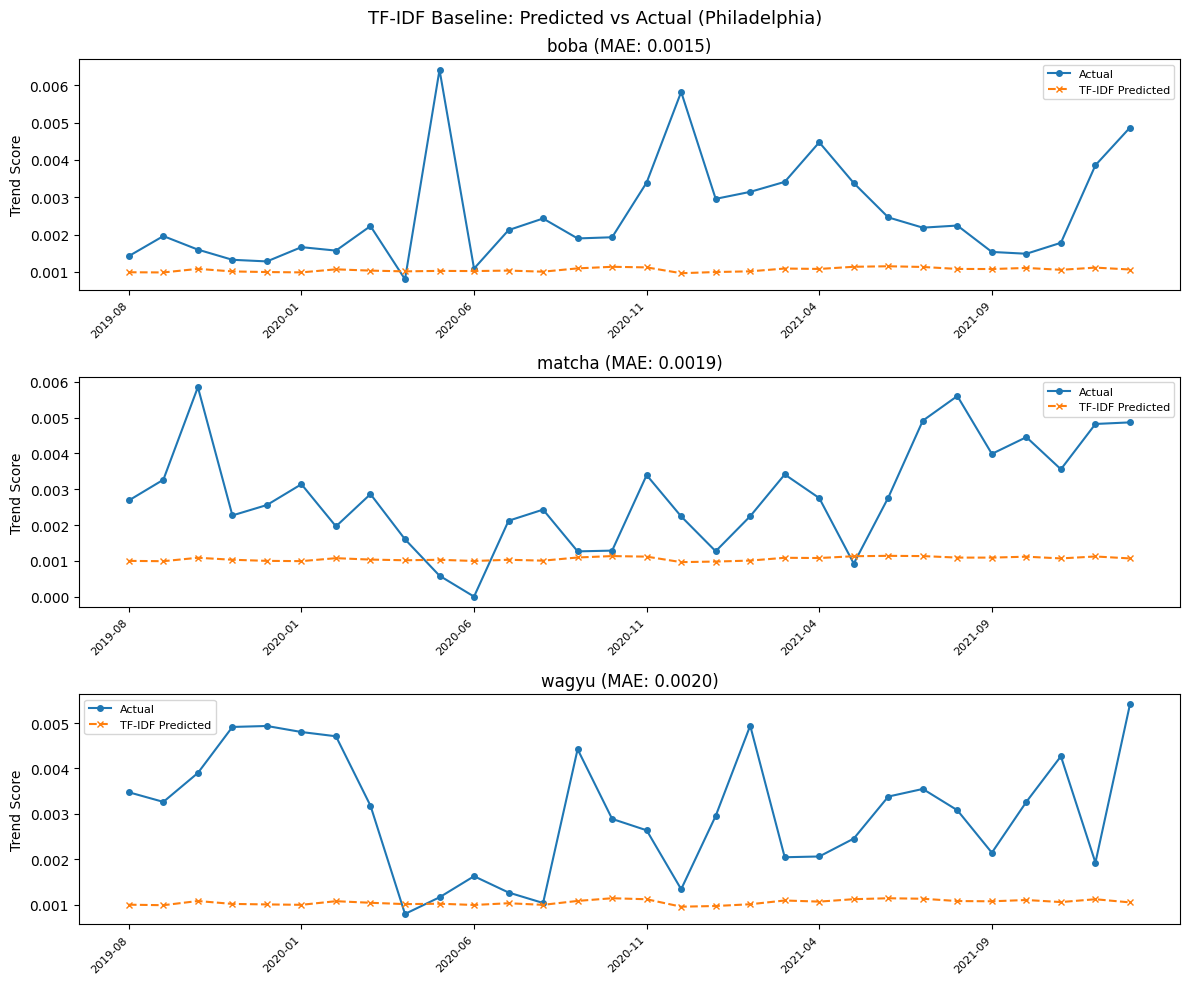

Plot saved for Philadelphia.


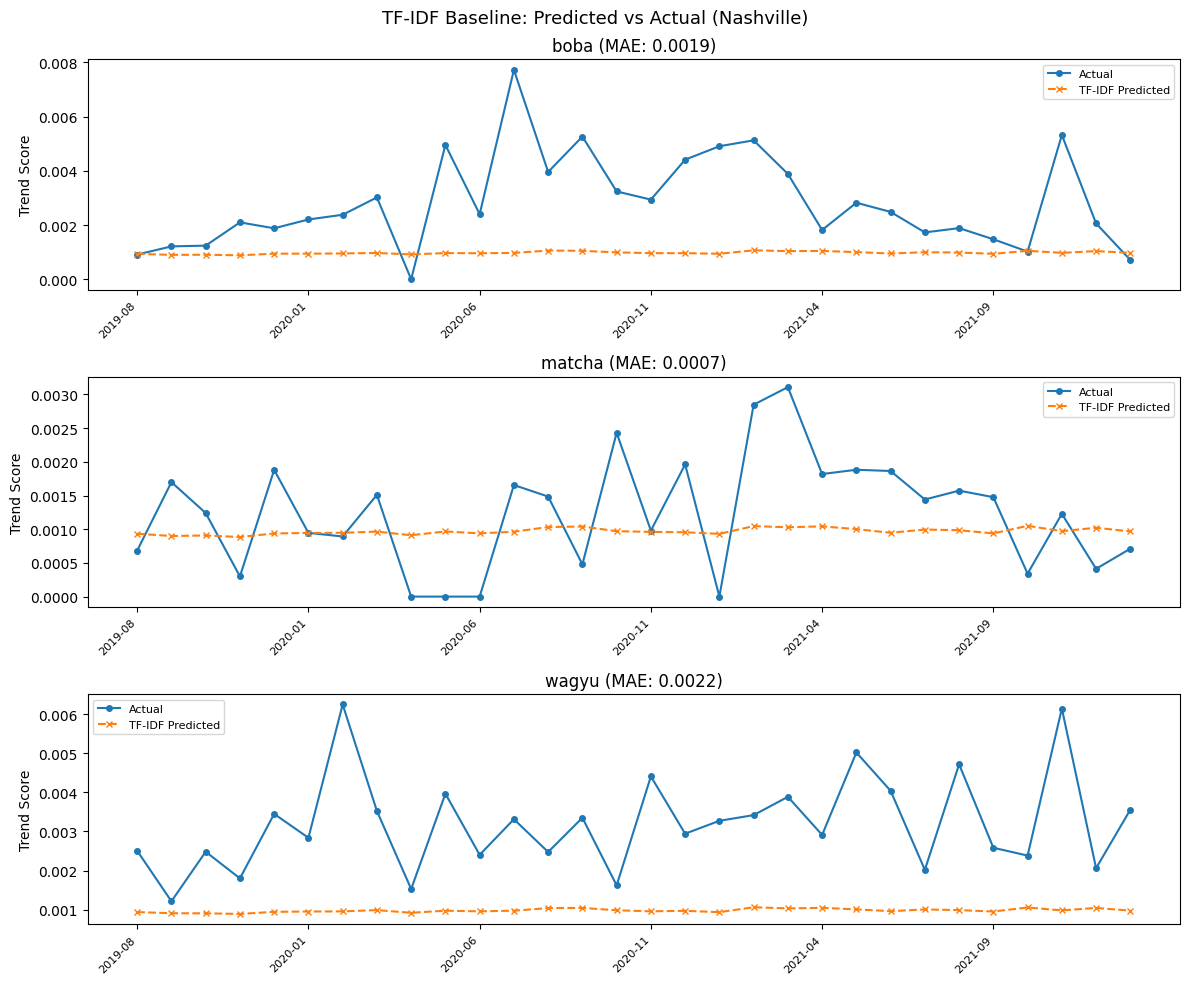

Plot saved for Nashville.


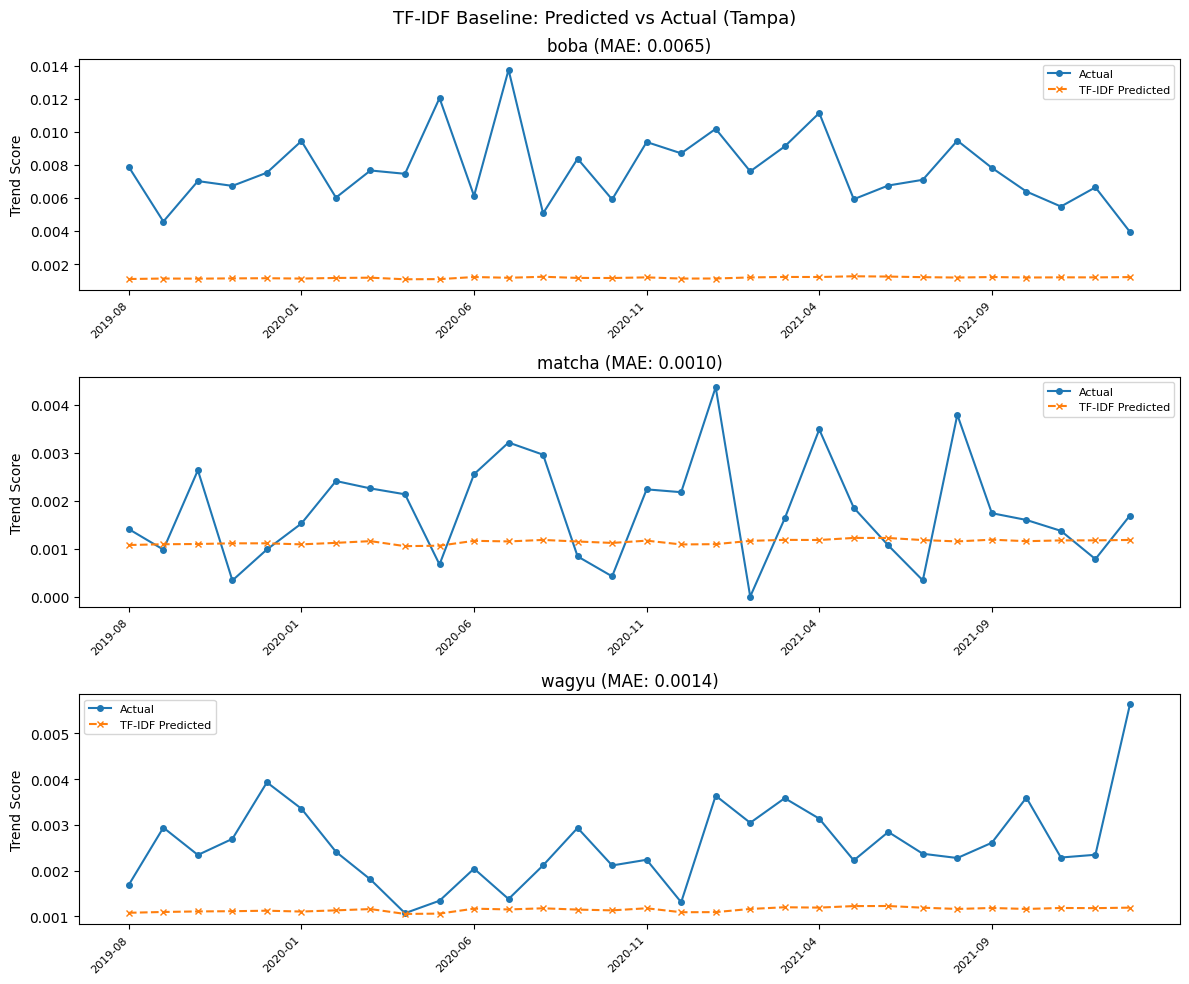

Plot saved for Tampa.


In [ ]:
#Plot predicted vs actual for 3 keywords in Philadelphia
keywords_to_plot = ['boba', 'matcha', 'wagyu']
cities_to_plot   = ['Philadelphia', 'Nashville', 'Tampa']

for city_to_plot in cities_to_plot:
    fig, axes = plt.subplots(len(keywords_to_plot), 1, figsize=(12, 10))

    for ax, kw in zip(axes, keywords_to_plot):
        subset = meta_test[
            (meta_test['keyword'] == kw) & (meta_test['city'] == city_to_plot)
        ].sort_values('next_month').reset_index(drop=True)

        if subset.empty:
            ax.set_title(f'{kw} - no test data'); continue

        ax.plot(range(len(subset)), subset['actual'], label='Actual', marker='o', markersize=4)
        ax.plot(range(len(subset)), subset['pred'],   label='TF-IDF Predicted',
                marker='x', markersize=4, linestyle='--')

        n    = len(subset)
        step = max(n // 6, 1)
        ax.set_xticks(range(0, n, step))
        ax.set_xticklabels([subset['next_month'].iloc[i] for i in range(0, n, step)],
                           rotation=45, ha='right', fontsize=8)
        mae_val = mean_absolute_error(subset['actual'], subset['pred'])
        ax.set_title(f"{kw} (MAE: {mae_val:.4f})")
        ax.set_ylabel('Trend Score')
        ax.legend(fontsize=8)

    plt.suptitle(f'TF-IDF Baseline: Predicted vs Actual ({city_to_plot})', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{BASE}/tfidf_predictions_{city_to_plot}.png', dpi=150)
    plt.show()
    print(f'Plot saved for {city_to_plot}.')

In [ ]:
#Save predictions for comparison with BERT later
meta_test.to_parquet(f'{BASE}/tfidf_test_predictions.parquet', index=False)
print('Saved tfidf_test_predictions.parquet')
print(f'\nFinal Test MAE: {mean_absolute_error(y_test, test_preds):.4f}')

Saved tfidf_test_predictions.parquet

Final Test MAE: 0.0014
